# Phase 3 — A Real Analysis, and the One Word That Decides If Your Numbers Mean Anything

Phases 1 and 2 taught the buttons. This phase uses them on a real question — *how are these
three restaurants doing?* — and drills the single idea that separates a correct answer from
a confidently wrong one: **`axis`**.

### Why `axis` deserves a whole notebook

Picture a spreadsheet: six years going down, three restaurants going across.

Now someone says "give me the total". **Which total?**
- Add each column downwards → one number per restaurant → *"how much has each shop made?"*
- Add each row across → one number per year → *"how did the business do each year?"*

Same data, same `sum`, completely different questions. `axis` is how you say which one you
meant. Get it backwards and NumPy won't complain — it'll just hand you the wrong answer
with total confidence.

### What this notebook covers
1. The data
2. The `axis` rule, stated once, properly
3. Totals and averages — per restaurant vs per year
4. Answering "*which* one?" with `argmax`
5. Spotting trends with `np.diff`
6. Working out percentages of a total
7. Running totals and charts
8. Vector maths: dot products, lengths, and measuring similarity
9. Working with text

In [1]:
# ==========================================
# SETUP
# ==========================================
import numpy as np
import matplotlib.pyplot as plt          # for the charts later on

## 1. The data

Six years of revenue for three restaurants. Column 0 holds the year number; columns 1, 2
and 3 hold the money.

**A habit worth forming right now:** don't leave yourself writing `sales_data[:, 2]` and
trying to remember which shop that was. Pull the labels into their own array and slice the
numbers out once, up front. Your code then reads like English, and you stop making
off-by-one mistakes.

In [2]:
# ==========================================
# 1. LOADING AND LABELLING THE DATA
# ==========================================
sales_data = np.array([
    # year, restaurant1, restaurant2, restaurant3
    [1, 4134, 23925,  8657],
    [2, 4116, 23875,  9142],
    [3, 4673, 27197, 10645],
    [4, 4580, 25637, 10456],
    [5, 5109, 27995, 11299],
    [6, 5011, 27419, 10625],
])

# Split the labels away from the numbers, once, so we never mix them up again
years       = sales_data[:, 0]        # just the year column
sales       = sales_data[:, 1:]       # everything EXCEPT the year column — the money
restaurants = np.array(['Biryani House', 'Chinese Wok', 'Pizza Palace'])

print("full table :", sales_data.shape, "→ 6 years, 4 columns (1 label + 3 restaurants)")
print("sales only :", sales.shape,      "→ 6 rows (years) by 3 columns (restaurants)")
print("\nthe first three years:\n", sales_data[:3])

full table : (6, 4) → 6 years, 4 columns (1 label + 3 restaurants)
sales only : (6, 3) → 6 rows (years) by 3 columns (restaurants)

the first three years:
 [[    1  4134 23925  8657]
 [    2  4116 23875  9142]
 [    3  4673 27197 10645]]


## 2. The `axis` rule

Here it is, and it's worth reading twice:

> ### **`axis` names the direction that gets squashed flat.**

Not the direction you keep — the direction that **disappears**.

Our `sales` array is 6 years tall and 3 restaurants wide:

| What you write | What gets squashed | What comes out | In English |
|---|---|---|---|
| `sales.sum(axis=0)` | the **years** | 3 numbers | total **for each restaurant**, all years combined |
| `sales.sum(axis=1)` | the **restaurants** | 6 numbers | total **for each year**, all shops combined |
| `sales.sum()` | everything | 1 number | the grand total |

**Two tricks that make this stick:**

- **`axis=0` goes down. `axis=1` goes across.** (0 looks like a tall column, 1 like a
  sideways line, if that helps.)
- **Count the answers.** Got 3 numbers back? There are 3 restaurants, so it's per
  restaurant. Got 6? There are 6 years, so it's per year. The length of the result tells
  you what you actually computed — check it every time until it's automatic.

In [3]:
# ==========================================
# 2. PROVING THE RULE BY COUNTING THE ANSWERS
# ==========================================
print("we start with       :", sales.shape, "→ 6 years x 3 restaurants")
print("sum(axis=0) gives   :", sales.sum(axis=0).shape,
      "→ 3 numbers, and there are 3 RESTAURANTS")
print("sum(axis=1) gives   :", sales.sum(axis=1).shape,
      "→ 6 numbers, and there are 6 YEARS")
print("sum() gives         :", np.shape(sales.sum()),
      "→ no shape at all: a single grand total")

we start with       : (6, 3) → 6 years x 3 restaurants
sum(axis=0) gives   : (3,) → 3 numbers, and there are 3 RESTAURANTS
sum(axis=1) gives   : (6,) → 6 numbers, and there are 6 YEARS
sum() gives         : () → no shape at all: a single grand total


> ### ⚠️ Slice the label column off first
>
> If you total up the **whole** table, NumPy happily adds the year column too — giving you
> `1+2+3+4+5+6 = 21`, a number that means absolutely nothing.
>
> NumPy can't tell a label from a measurement. That's your job.

In [4]:
print("totalling the FULL table :", np.sum(sales_data, axis=0))
print("                             ↑ that 21 is just the year numbers added up. Nonsense.")
print("totalling the money only :", np.sum(sales, axis=0), "← the number you actually want")

totalling the FULL table : [    21  27623 156048  60824]
                             ↑ that 21 is just the year numbers added up. Nonsense.
totalling the money only : [ 27623 156048  60824] ← the number you actually want


## 3. Totals and averages

Now that the rule is clear, both questions become easy. Notice how the two cells below are
nearly identical — the only real difference is `axis=0` versus `axis=1`.

In [5]:
# ==========================================
# 3a. PER RESTAURANT — squash the years away (axis=0)
# ==========================================
total_per_restaurant = sales.sum(axis=0)      # lifetime takings for each shop
avg_per_restaurant   = sales.mean(axis=0)     # typical year for each shop
best_year_value      = sales.max(axis=0)      # each shop's best year
worst_year_value     = sales.min(axis=0)      # each shop's worst year

print("=== HOW HAS EACH RESTAURANT DONE? ===")
for name, total, avg, hi, lo in zip(restaurants, total_per_restaurant,
                                    avg_per_restaurant, best_year_value, worst_year_value):
    print(f"{name:<15} total={total:>7,}  avg={avg:>9,.0f}  best={hi:>6,}  worst={lo:>6,}")

=== HOW HAS EACH RESTAURANT DONE? ===
Biryani House   total= 27,623  avg=    4,604  best= 5,109  worst= 4,116
Chinese Wok     total=156,048  avg=   26,008  best=27,995  worst=23,875
Pizza Palace    total= 60,824  avg=   10,137  best=11,299  worst= 8,657


In [6]:
# ==========================================
# 3b. PER YEAR — squash the restaurants away (axis=1)
# ==========================================
total_per_year = sales.sum(axis=1)            # everything the business took that year
avg_per_year   = sales.mean(axis=1)           # the typical shop that year
min_per_year   = sales.min(axis=1)            # the weakest shop that year

print("=== HOW HAS THE BUSINESS DONE EACH YEAR? ===")
for y, total, avg, lo in zip(years, total_per_year, avg_per_year, min_per_year):
    print(f"Year {y}  total={total:>7,}  avg={avg:>9,.0f}  weakest shop={lo:>6,}")

print("\nGrand total, all shops, all years:", f"{sales.sum():,}")

=== HOW HAS THE BUSINESS DONE EACH YEAR? ===
Year 1  total= 36,716  avg=   12,239  weakest shop= 4,134
Year 2  total= 37,133  avg=   12,378  weakest shop= 4,116
Year 3  total= 42,515  avg=   14,172  weakest shop= 4,673
Year 4  total= 40,673  avg=   13,558  weakest shop= 4,580
Year 5  total= 44,403  avg=   14,801  weakest shop= 5,109
Year 6  total= 43,055  avg=   14,352  weakest shop= 5,011

Grand total, all shops, all years: 244,495


### Averages hide things — check how bumpy the numbers are

Two restaurants can average the same revenue while one is steady as a rock and the other
swings wildly. The average can't tell you that; **standard deviation** can. It's one number
answering *"how far from the average does this typically stray?"*

But there's a catch. A shop earning 27,000 will naturally have bigger swings than one
earning 5,000, just because the numbers are bigger. So a raw standard deviation isn't fair
to compare between them.

The fix is simple: **divide the standard deviation by the average.** That converts it into a
percentage — *"it typically strays about 8% from its usual"* — which you *can* compare
across shops of any size. Statisticians call this the coefficient of variation; you can just
call it bumpiness.

In [7]:
# ==========================================
# 3c. WHICH SHOP IS THE STEADIEST?
# ==========================================
std_per_restaurant = sales.std(axis=0)                     # raw swing size, in money
bumpiness = std_per_restaurant / avg_per_restaurant        # swing as a % of normal

for name, s, b in zip(restaurants, std_per_restaurant, bumpiness):
    print(f"{name:<15} typical swing = {s:>7,.0f}   as a share of normal = {b:.1%}")

print("\nSteadiest earner:", restaurants[np.argmin(bumpiness)])
print("(Chinese Wok has the BIGGEST raw swings but the SMALLEST relative ones —")
print(" that's exactly why dividing by the average matters.)")

Biryani House   typical swing =     384   as a share of normal = 8.3%
Chinese Wok     typical swing =   1,652   as a share of normal = 6.4%
Pizza Palace    typical swing =     925   as a share of normal = 9.1%

Steadiest earner: Chinese Wok
(Chinese Wok has the BIGGEST raw swings but the SMALLEST relative ones —
 that's exactly why dividing by the average matters.)


## 4. Answering "*which* one?"

`max` tells you the biggest **value**. `argmax` tells you **where** it is — its position.

That position is the useful part, because you can feed it into your labels array and get a
name back. `max` says "156,048". `argmax` plus labels says "Chinese Wok". Only one of those
is a usable answer.

Think of `arg` as short for "**which one**".

In [8]:
# ==========================================
# 4. FINDING THE WINNER, NOT JUST THE WINNING NUMBER
# ==========================================

# Step A: find the POSITION of the biggest and smallest totals
best_idx  = np.argmax(total_per_restaurant)
worst_idx = np.argmin(total_per_restaurant)

# Step B: use those positions to look up the NAMES
print("Top earner   :", restaurants[best_idx],  f"({total_per_restaurant[best_idx]:,})")
print("Lowest earner:", restaurants[worst_idx], f"({total_per_restaurant[worst_idx]:,})")

# Same trick down the columns: which YEAR was each shop's best?
peak_year_idx = np.argmax(sales, axis=0)          # one row-position per restaurant
print()
for col, name in enumerate(restaurants):
    row = peak_year_idx[col]                      # which year that shop peaked in
    print(f"{name:<15} peaked in year {int(years[row])} with {sales[row, col]:,}")

# And a full ranking: argsort gives worst-to-best, so [::-1] flips it to best-first
ranking = np.argsort(total_per_restaurant)[::-1]
print("\nFull ranking:", " > ".join(restaurants[ranking]))

Top earner   : Chinese Wok (156,048)
Lowest earner: Biryani House (27,623)

Biryani House   peaked in year 5 with 5,109
Chinese Wok     peaked in year 5 with 27,995
Pizza Palace    peaked in year 5 with 11,299

Full ranking: Chinese Wok > Pizza Palace > Biryani House


## 5. Spotting trends with `np.diff`

`np.diff` answers "how much did it change each step?" It subtracts each value from the one
after it. Down the years (`axis=0`), that's year-on-year growth.

**Expect one fewer row than you started with.** Six years only have five gaps between them —
there's no "change" for year 1, because nothing came before it.

To turn those changes into percentages, divide by the year *before* — that's what
`sales[:-1]` means ("everything except the last row").

In [9]:
# ==========================================
# 5. YEAR-ON-YEAR GROWTH
# ==========================================

# Step A: the raw change from each year to the next
yoy_change = np.diff(sales, axis=0)                # 5 rows, not 6 — see the note above

# Step B: turn it into a percentage of where we started from
yoy_pct = yoy_change / sales[:-1] * 100            # sales[:-1] = every year but the last

print("change in money terms:\n", yoy_change)

print("\nchange as a percentage:")
print(f"{'':<15}" + "".join(f"Y{int(y)}->Y{int(y)+1}".rjust(9) for y in years[:-1]))
for name, row in zip(restaurants, yoy_pct.T):      # .T flips it so each row is one shop
    print(f"{name:<15}" + "".join(f"{v:+.1f}%".rjust(9) for v in row))

# Step C: the big picture — first year compared to last
overall_growth = (sales[-1] - sales[0]) / sales[0] * 100
print("\ngrowth over the whole six years:")
for name, g in zip(restaurants, overall_growth):
    print(f"  {name:<15} {g:+.1f}%")

change in money terms:
 [[  -18   -50   485]
 [  557  3322  1503]
 [  -93 -1560  -189]
 [  529  2358   843]
 [  -98  -576  -674]]

change as a percentage:
                  Y1->Y2   Y2->Y3   Y3->Y4   Y4->Y5   Y5->Y6
Biryani House      -0.4%   +13.5%    -2.0%   +11.6%    -1.9%
Chinese Wok        -0.2%   +13.9%    -5.7%    +9.2%    -2.1%
Pizza Palace       +5.6%   +16.4%    -1.8%    +8.1%    -6.0%

growth over the whole six years:
  Biryani House   +21.2%
  Chinese Wok     +14.6%
  Pizza Palace    +22.7%


## 6. Percentages of a total — and the `keepdims` trick

Say you want each year's numbers as a share of that year's total: *"Chinese Wok was 65% of
our business in year 1."*

The obvious code is `sales / sales.sum(axis=1)` — and it fails with an error. Here's why,
because the reason is worth understanding.

When NumPy combines two arrays of different sizes it lines them up **from the right-hand
end**, like adding up numbers on paper:

```
   sales:  (6, 3)          sales:  (6, 3)
  totals:     (6,)   ✗    totals:  (6, 1)   ✓
           ↑ 3 vs 6                 ↑ 3 vs 1 — a 1 stretches to fit
```

`sum(axis=1)` squashes the restaurant direction away completely, leaving a flat run of 6
numbers. Lined up from the right, that 6 sits under the 3 — and 6 doesn't match 3.

**`keepdims=True` fixes it.** Instead of removing the squashed direction, it leaves it behind
as a placeholder of width 1. You get `(6, 1)` — a proper column — and a width of 1 is
allowed to stretch. Now it lines up.

Whenever you want to divide each row by something about that row, `keepdims=True` is the
answer.

In [10]:
# ==========================================
# 6. EACH YEAR AS PERCENTAGES
# ==========================================
row_totals_flat = sales.sum(axis=1)                   # (6,)   — flat, won't line up
row_totals_keep = sales.sum(axis=1, keepdims=True)    # (6, 1) — a column, lines up fine

print("without keepdims:", row_totals_flat.shape, "← a flat run of 6 numbers")
print("with keepdims   :", row_totals_keep.shape, "← a proper column of 6")

# Here's the failure, so you recognise the error message when you hit it:
try:
    sales / row_totals_flat
except ValueError as e:
    print("\nthe flat version fails →", e)

# And the version that works:
market_share = sales / row_totals_keep * 100

print("\nshare of each year's takings (every row adds up to 100%):")
print(f"{'Year':<6}" + "".join(f"{n:>15}" for n in restaurants))
for y, row in zip(years, market_share):
    print(f"{int(y):<6}" + "".join(f"{v:>14.1f}%" for v in row))

without keepdims: (6,) ← a flat run of 6 numbers
with keepdims   : (6, 1) ← a proper column of 6

the flat version fails → operands could not be broadcast together with shapes (6,3) (6,) 

share of each year's takings (every row adds up to 100%):
Year    Biryani House    Chinese Wok   Pizza Palace
1               11.3%          65.2%          23.6%
2               11.1%          64.3%          24.6%
3               11.0%          64.0%          25.0%
4               11.3%          63.0%          25.7%
5               11.5%          63.0%          25.4%
6               11.6%          63.7%          24.7%


## 7. Running totals and charts

`np.cumsum` ("cumulative sum") gives a **running total** — each row adds itself to everything
before it. Down the years, that's "money earned so far", the shape of a bank balance.

Then we plot it. And this is where getting `axis` wrong shows up as an obviously silly
chart, which is a nice safety net: **if you ask for a line over time and get 3 dots, you
squashed the wrong direction.**

In [11]:
# ==========================================
# 7a. RUNNING TOTAL
# ==========================================
cumulative = np.cumsum(sales, axis=0)      # add each year onto the years before it

print("money earned so far (rows = years, columns = restaurants):\n", cumulative)
print("\nthe last row is lifetime earnings:", cumulative[-1])

money earned so far (rows = years, columns = restaurants):
 [[  4134  23925   8657]
 [  8250  47800  17799]
 [ 12923  74997  28444]
 [ 17503 100634  38900]
 [ 22612 128629  50199]
 [ 27623 156048  60824]]

the last row is lifetime earnings: [ 27623 156048  60824]


mean(cumulative, axis=1) gives (6,) → 6 numbers, one per year ✓ that's a time series
mean(cumulative, axis=0) gives (3,) → 3 numbers, one per shop ✗ plotting this over 'years' would be nonsense


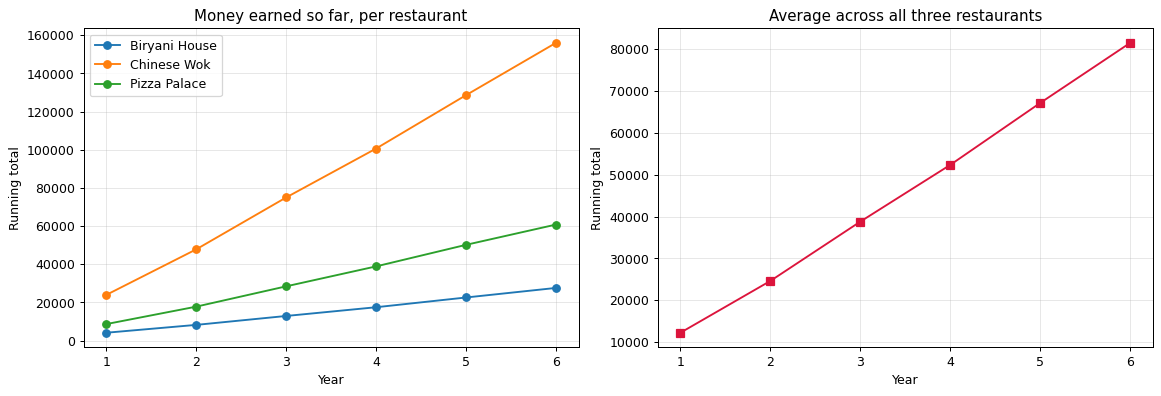

In [12]:
# ==========================================
# 7b. TWO CHARTS — AND AN axis WARNING
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))    # one figure, two charts side by side

# --- LEFT CHART: one line per restaurant ---
# Column i is restaurant i's numbers over time, so we plot each column against the years
for i, name in enumerate(restaurants):
    axes[0].plot(years, cumulative[:, i], marker='o', label=name)
axes[0].set_title("Money earned so far, per restaurant")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Running total")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# --- RIGHT CHART: the average across the three shops ---
# We want ONE number per year, so we squash the RESTAURANT direction → axis=1.
# Using axis=0 here would squash time instead and leave 3 dots. Not a time series.
avg_cumulative = np.mean(cumulative, axis=1)
axes[1].plot(years, avg_cumulative, marker='s', color='crimson')
axes[1].set_title("Average across all three restaurants")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Running total")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("mean(cumulative, axis=1) gives", avg_cumulative.shape,
      "→ 6 numbers, one per year ✓ that's a time series")
print("mean(cumulative, axis=0) gives", np.mean(cumulative, axis=0).shape,
      "→ 3 numbers, one per shop ✗ plotting this over 'years' would be nonsense")

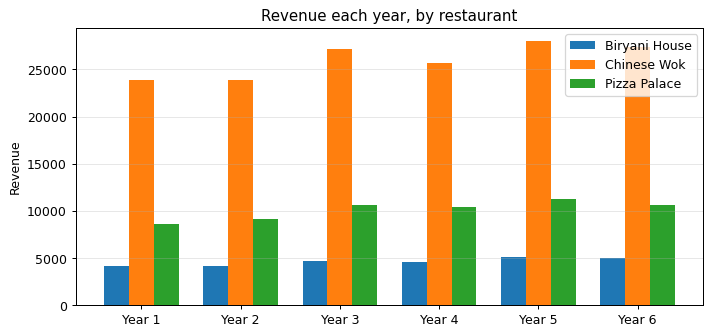

In [13]:
# ==========================================
# 7c. A BAR CHART OF EACH YEAR
# ==========================================
x = np.arange(len(years))       # positions 0..5 along the bottom
width = 0.25                    # each bar is a quarter as wide as one slot

plt.figure(figsize=(9, 4))
for i, name in enumerate(restaurants):
    # nudge each shop's bars sideways so all three fit within one year's slot
    plt.bar(x + i * width, sales[:, i], width, label=name)

plt.xticks(x + width, [f"Year {int(y)}" for y in years])   # labels under the middle bar
plt.ylabel("Revenue")
plt.title("Revenue each year, by restaurant")
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## 8. Vector maths

A "vector" is just a row of numbers — which you already have. But a few standard operations
on them power an enormous amount of machine learning, so they're worth meeting now.

The big one is the **dot product**: multiply the two rows together item by item, then add up
the results. One number out.

That sounds arbitrary until you know what it's *for*: it measures **how much two rows point
in the same direction**. Every recommendation engine ("people who liked this…"), every
search-by-meaning feature, and every single layer of a neural network is built on it.

In [14]:
# ==========================================
# 8a. THE DOT PRODUCT
# ==========================================
v1 = np.array([1, 2, 3, 4, 5])
v2 = np.array([6, 7, 8, 9, 10])

print("adding them      :", v1 + v2, "← item by item")
print("multiplying them :", v1 * v2, "← still item by item. This is NOT a dot product.")
print("dot product      :", np.dot(v1, v2),
      "← multiply item by item, THEN add it all up:", (v1 * v2).sum())
print("the shorthand    :", v1 @ v2, "← the @ symbol means the same thing, less typing")

adding them      : [ 7  9 11 13 15] ← item by item
multiplying them : [ 6 14 24 36 50] ← still item by item. This is NOT a dot product.
dot product      : 130 ← multiply item by item, THEN add it all up: 130
the shorthand    : 130 ← the @ symbol means the same thing, less typing


### Length, and comparing shapes instead of sizes

The **norm** of a vector is its length — straight-line distance from zero, exactly the
Pythagoras you learned at school. `[3, 4]` has length 5.

Now the useful bit. Suppose you want to know whether two restaurants **rise and fall
together**, regardless of one being five times bigger. Comparing raw numbers won't tell you
that — the big shop swamps the small one.

**Cosine similarity** solves it. It divides out the sizes and compares only the *shape* of
the pattern:
- **1.0** → they move in perfect lockstep
- **0** → no relationship at all
- **−1** → perfect opposites; one rises exactly as the other falls

In [15]:
# ==========================================
# 8b. LENGTHS AND SIMILARITY
# ==========================================
print("straight-line length of v1:", np.linalg.norm(v1).round(4))
print("add up the sizes ignoring +/-:", np.linalg.norm(v1, ord=1))

# Cosine similarity = dot product, divided by both lengths (which cancels out size)
cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# np.clip is safety padding — see the note below
angle_rad = np.arccos(np.clip(cos_sim, -1.0, 1.0))

print("\nsimilarity (1.0 = identical direction):", cos_sim.round(4))
print("as an angle, in radians               :", angle_rad.round(4))
print("as an angle, in degrees               :", np.degrees(angle_rad).round(2),
      "← show people this one")

straight-line length of v1: 7.4162
add up the sizes ignoring +/-: 15.0

similarity (1.0 = identical direction): 0.965
as an angle, in radians               : 0.2655
as an angle, in degrees               : 15.21 ← show people this one


> **Why the `np.clip` in there?** Cosine similarity is meant to land between −1 and 1.
> But computers store decimals with tiny rounding errors, so it can come out as
> `1.0000000002`. Ask for the angle of something above 1 and you get `nan` ("not a number"),
> which then silently poisons everything downstream. `np.clip(x, -1, 1)` pins it back inside
> the legal range. One cheap call, one whole class of bug gone.

In [16]:
# ==========================================
# 8c. WHICH TWO RESTAURANTS BEHAVE MOST ALIKE?
# ==========================================
# Comparing the SHAPE of each revenue curve, ignoring how big the shop is
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

for i in range(len(restaurants)):
    for j in range(i + 1, len(restaurants)):        # each pair once, no repeats
        s = cosine(sales[:, i], sales[:, j])
        print(f"{restaurants[i]:<15} vs {restaurants[j]:<15} → {s:.5f}")

print("\nAll three are within a whisker of 1.0, meaning they rise and fall together.")
print("Sensible: good years are good for everyone (holidays, the local economy, and so on).")

Biryani House   vs Chinese Wok     → 0.99964
Biryani House   vs Pizza Palace    → 0.99949
Chinese Wok     vs Pizza Palace    → 0.99932

All three are within a whisker of 1.0, meaning they rise and fall together.
Sensible: good years are good for everyone (holidays, the local economy, and so on).


## 9. Working with text

Arrays can hold words as well as numbers. The fast, built-in text tools live in `np.char`.

⚠️ **A warning about `np.vectorize`.** The name promises speed and does not deliver. It's a
convenience wrapper that makes your *code* look array-shaped while still running an ordinary
Python loop underneath. Fine for tidiness; useless for performance. When speed matters, use
`np.char` (or pandas).

In [17]:
# ==========================================
# 9. TEXT ARRAYS
# ==========================================
names = np.array(['biryani house', 'chinese wok', 'pizza palace'])

print("uppercase        :", np.char.upper(names))
print("title case       :", np.char.title(names))
print("length of each   :", np.char.str_len(names))
print("starts with 'p'? :", np.char.startswith(names, 'p'), "← a True/False mask, as usual")
print("keep only 'c' ones:", names[np.char.startswith(names, 'c')], "← mask used to filter")

# np.vectorize takes any Python function you like — just don't expect it to be fast
first_word = np.vectorize(lambda s: s.split()[0])
print("\nfirst word of each:", first_word(names))

uppercase        : ['BIRYANI HOUSE' 'CHINESE WOK' 'PIZZA PALACE']
title case       : ['Biryani House' 'Chinese Wok' 'Pizza Palace']
length of each   : [13 11 12]
starts with 'p'? : [False False  True] ← a True/False mask, as usual
keep only 'c' ones: ['chinese wok'] ← mask used to filter

first word of each: ['biryani' 'chinese' 'pizza']


## 10. Dividing by a single number

Divide an array by one number and every item gets divided. No loop. NumPy calls this
**broadcasting** — the single number is "broadcast" out to meet every item. Phase 5 covers
the full rules; for now, just enjoy that it works.

Here we turn yearly revenue into an average month.

In [18]:
# ==========================================
# 10. YEARLY REVENUE → AVERAGE MONTH
# ==========================================
monthly_avg = sales / 12          # one number, applied to all 18 values at once

print("average takings per month:")
print(f"{'Year':<6}" + "".join(f"{n:>15}" for n in restaurants))
for y, row in zip(years, monthly_avg):
    print(f"{int(y):<6}" + "".join(f"{v:>15,.0f}" for v in row))

average takings per month:
Year    Biryani House    Chinese Wok   Pizza Palace
1                 344          1,994            721
2                 343          1,990            762
3                 389          2,266            887
4                 382          2,136            871
5                 426          2,333            942
6                 418          2,285            885


## Cheat sheet

| The question you're asking | What to type |
|---|---|
| Total for each column (squash the rows) | `a.sum(axis=0)` |
| Total for each row (squash the columns) | `a.sum(axis=1)` |
| Keep the squashed direction so shapes line up | `a.sum(axis=1, keepdims=True)` |
| *Which* one is biggest? | `labels[np.argmax(values)]` |
| Rank them all | `labels[np.argsort(values)[::-1]]` |
| How much did it change each step? | `np.diff(a, axis=0)` |
| Running total | `np.cumsum(a, axis=0)` |
| Do these two move together? | `a @ b / (norm(a) * norm(b))` |
| Text operations | `np.char.upper`, `np.char.startswith`, … |

### The three things worth memorising

1. **`axis` is the direction that gets squashed away.** Count the answers to check: 3 back
   means per restaurant, 6 back means per year.
2. **Strip the label columns off before you total anything**, or you'll add up row numbers
   and get a meaningless answer with no warning.
3. **`keepdims=True`** is what makes "divide each row by its own total" work.

### Practice

1. Which restaurant had the single biggest **one-year** jump, and in which year?
   *(Hint: `np.diff`, then `np.unravel_index(np.argmax(d), d.shape)` to turn the position
   back into a row and column.)*
2. Add a fourth restaurant column of your own and re-run the totals. Does any code need
   changing? (It shouldn't — that's the payoff for not hard-coding `3` everywhere.)
3. Find every year-and-restaurant combination that beat 25,000, using a mask.
4. Work out each restaurant's share of the six-year grand total — three numbers adding
   to 100%.

In [19]:
# ==========================================
# PRACTICE 1 — worked solution
# ==========================================
d = np.diff(sales, axis=0)                            # every year-to-year change

# argmax on a table gives ONE number, counted as if the table were flattened out.
# unravel_index turns that back into a (row, column) pair we can actually use.
row, col = np.unravel_index(np.argmax(d), d.shape)

print(f"Biggest jump: {restaurants[col]} gained {d[row, col]:,} "
      f"between year {int(years[row])} and year {int(years[row + 1])}")

# ==========================================
# PRACTICE 4 — worked solution
# ==========================================
share = sales.sum(axis=0) / sales.sum() * 100         # each shop's total ÷ everyone's total
print()
for name, s in zip(restaurants, share):
    print(f"{name:<15} {s:5.1f}% of everything earned")

Biggest jump: Chinese Wok gained 3,322 between year 2 and year 3

Biryani House    11.3% of everything earned
Chinese Wok      63.8% of everything earned
Pizza Palace     24.9% of everything earned
